In [2]:
from sklearn.compose import ColumnTransformer

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

from collections import Counter


## Data filtering and merging

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_ori = pd.read_csv('Assignment1_mimic dataset.csv', index_col=['subject_id', 'hadm_id', 'stay_id'])
df_ori.drop('deathtime',axis=1,inplace=True)
df_ori.drop('hospital_expire_flag',axis=1,inplace=True)
df_ori.drop('outtime',axis=1,inplace=True)
df_ori.drop('intime',axis=1,inplace=True)
reference_cols = ['los']
df = df_ori.copy()
df.drop('los',axis=1,inplace=True)

all_white = df['race'].str.contains('white',case=False)
df.loc[all_white,'race'] = 'WHITE'
all_black = df['race'].str.contains('black',case=False)
df.loc[all_black,'race'] = 'BLACK'
all_asian = df['race'].str.contains('asian',case=False)
df.loc[all_asian,'race'] = 'ASIAN'
latin = df['race'].str.contains('hispanic',case=False)
df.loc[latin,'race'] = 'HIAPANIC/LATINO'
all_unknown = ['UNKNOWN','UNABLE TO OBTAIN','PATIENT DECLINED TO ANSWER']
df['race'] = df['race'].replace(all_unknown,'UNKNOWN')
all_other = ['OTHER','MULTIPLE RACE/ETHNICITY']
df['race'] = df['race'].replace(all_other,'OTHER')
all_latin = ['HIAPANIC/LATINO','SOUTH AMERICAN']
df['race'] = df['race'].replace(all_latin,'HIAPANIC LATINO')
api = ['ASIAN','NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER']
df['race'] = df['race'].replace(api,'ASIAN/PACIFIC ISLANDER')

df['insurance'] = df['insurance'].replace('No charge','Other')

neural_careunit = ['Neuro Intermediate','Neuro Surgical Intensive Care Unit (Neuro SICU)','Neuro Stepdown','Neurology']
other_careunit = ['Surgery/Vascular/Intermediate','PACU','Intensive Care Unit (ICU)','Medicine','Surgery/Trauma','Med/Surg']
df['first_careunit'] = df['first_careunit'].replace(neural_careunit,'Neuro ICU')
df['last_careunit'] = df['last_careunit'].replace(neural_careunit,'Neuro ICU')
df['first_careunit'] = df['first_careunit'].replace(other_careunit,'Other')
df['last_careunit'] = df['last_careunit'].replace(other_careunit,'Other')

asian_language = ['Chinese','Vietnamese','Khmer','Korean','Hindi','Thai','Bengali','Japanese']
middle_eastern_language = ['Modern Greek (1453-)','Arabic','Persian','Armenian']
slavic_language = ['Russian','Polish']
african_language = ['Kabuverdianu','Amharic','Somali']
romance_language = ['Spanish','Portuguese','Italian','French']
df['language'] = df['language'].replace('Haitian','Other')
df['language'] = df['language'].replace(asian_language,'Asian')
df['language'] = df['language'].replace(middle_eastern_language,'Mid-Eastern')
df['language'] = df['language'].replace(slavic_language,'Slavic')
df['language'] = df['language'].replace(african_language,'African')
df['language'] = df['language'].replace(romance_language,'Romance')

df['marital_status'] = df['marital_status'].fillna('UNKNOWN')

In [ ]:
missing_values = df.isnull().sum()
missing_ratio = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'num': missing_values,
    'missing %': missing_ratio
})
missing_df = missing_df[missing_df['num'] > 0].sort_values('missing %', ascending=False)
print(missing_df)
high_missing = missing_ratio[missing_ratio>60].index.tolist()
if high_missing:
    df.drop(columns=high_missing,inplace=True)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull().reset_index(drop=True), cmap='Blues', cbar=False)
plt.title("Missing Value")
plt.show()



X = df.drop('icu_death_flag',axis=1)
y = df['icu_death_flag']


In [ ]:
numerical_val = df.select_dtypes(include=['int64','float64'])
categorical_val = df.select_dtypes(include='str')
print('numerical variables:')
print(numerical_val.columns.tolist())
print('categorical variables:')
print(categorical_val.columns.tolist())

In [ ]:
def frequency_encode(df,categorical_cols):
    df_encoded = df.copy()
    for col in categorical_cols:
        freq = df[col].value_counts(normalize=True)
        df_encoded[f'{col}_freq'] = df[col].map(freq)

        print(f"\n Frequency coding of '{col}':")
        for val, f in freq.items():
            print(f"  {val}: {f:.3f}")
    return df_encoded

df_freq = frequency_encode(df, categorical_val)

In [ ]:
encoded_cat = [col for col in df_freq.columns if '_freq' in col]

numerical_col = numerical_val.columns.tolist()
all_numeric = encoded_cat + numerical_col

corr = df_freq[all_numeric].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
corr_with_target = df_freq[all_numeric].corr()['icu_death_flag'].drop('icu_death_flag')
corr_df = corr_with_target.to_frame()
plt.figure(figsize=(3,10))
sns.heatmap(corr_df, cmap="coolwarm",linewidths=0.2, cbar=True)
plt.title("Correlation between icu_death_flag and other feature", fontsize=12)
plt.show()

In [ ]:
corr_with_target.nlargest(20)

In [ ]:
target_distribution = df['icu_death_flag'].value_counts()
print(target_distribution)

# Distribution

In [10]:
data_cleaned = df_freq[all_numeric]
data_cleaned.shape

(65366, 46)

In [11]:
X = data_cleaned.drop(columns='icu_death_flag')
y = data_cleaned['icu_death_flag']

train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

encoded_cat = [col for col in X.columns if col.endswith('_freq')]
numeric_col = [col for col in X.columns if col not in encoded_cat + ['icu_death_flag']]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=42, stratify=y
)

val_size_relative = val_ratio / (train_ratio + val_ratio)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size_relative, random_state=42, stratify=y_train_val
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value= 0)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_col),
        ('cat', categorical_transformer, encoded_cat),
    ]
)

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

print('train_shape:', X_train_transformed.shape)
print('val_shape:', X_val_transformed.shape)
print('test_shape:', X_test_transformed.shape)

train_shape: (39219, 45)
val_shape: (13073, 45)
test_shape: (13074, 45)


In [12]:
print("X_train null？", np.isnan(X_train_transformed).any())
print("X_test null？", np.isnan(X_val_transformed).any())

X_train null？ False
X_test null？ False


## L1 regularization

In [13]:
if isinstance(X_train_transformed, np.ndarray):
    feature_names = numeric_col + encoded_cat
    X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
    X_val_df = pd.DataFrame(X_val_transformed, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

C_values =[0.001, 0.01, 0.1, 1, 10]
selected_features_dict = {}

for C in C_values:
    l1_logistic = LogisticRegression(
        l1_ratio=1, C=C, solver='saga',
        max_iter=5000, random_state=42,
        class_weight='balanced'
    )
    l1_logistic.fit(X_train_df, y_train)

    selected_mask = l1_logistic.coef_[0] != 0
    selected_features = X_train_df.columns[selected_mask].tolist()
    selected_features_dict[C] = selected_features

all_selected = []
for C,features in selected_features_dict.items():
    all_selected.extend(features)

feature_counts = Counter(all_selected)

stable_features = [i for i,count in feature_counts.items() if count == len(C_values)]
common_features = [i for i,count in feature_counts.items() if count >= len(C_values)//2]
print(f'Stable features: {stable_features}')
print(f'Common features: {common_features}')

Stable features: ['age', 'sofa2_cardiovascular_24h_max', 'sofa2_liver_24h_max', 'sofa2_renal_24h_max', 'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'mbp_min', 'resp_rate_mean', 'temperature_min', 'temperature_mean', 'spo2_min', 'spo2_mean', 'glucose_min', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'po2_max']
Common features: ['age', 'sofa2_cardiovascular_24h_max', 'sofa2_liver_24h_max', 'sofa2_renal_24h_max', 'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'mbp_min', 'resp_rate_mean', 'temperature_min', 'temperature_mean', 'spo2_min', 'spo2_mean', 'glucose_min', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'po2_max', 'sofa2_respiration_24h_max', 'sofa2_coagulation_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min', 'sbp_max', 'sbp_mean', 'dbp_min', 'dbp_max', 'resp_rate_min', 'glucose_max', 'po2_min', 'race_freq', 'marital_status_freq', 'mbp_max', 'mbp_mean', 'resp_rate_max', 'temperature_max', 'spo2_max', 'glucose_mean', 'gcs_min', 'gcs_unable', 'first_careunit_freq', 'last_careunit_freq', 'lan

In [14]:
results = []
for C in C_values:
    model = LogisticRegression(
        l1_ratio=1, C=C, solver='saga',
        max_iter=5000, random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train_df, y_train)

    y_train_pred = model.predict_proba(X_train_df)[:,1]
    y_val_pred = model.predict_proba(X_val_df)[:,1]

    train_auc = roc_auc_score(y_train, y_train_pred)
    val_auc = roc_auc_score(y_val, y_val_pred)

    n_selected = np.sum(model.coef_[0] != 0)

    overfitting = train_auc - val_auc

    results.append({
        'C': C,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'n_selected': n_selected,
        'overfitting': overfitting,
    })

    print(f"C={C:6}: Train AUC={train_auc:.4f}, Val AUC={val_auc:.4f}, "f"Diff={overfitting:.4f}, Features={n_selected:3d}")


C= 0.001: Train AUC=0.8886, Val AUC=0.8836, Diff=0.0051, Features= 18
C=  0.01: Train AUC=0.8951, Val AUC=0.8885, Diff=0.0065, Features= 31
C=   0.1: Train AUC=0.8970, Val AUC=0.8890, Diff=0.0080, Features= 42
C=     1: Train AUC=0.8972, Val AUC=0.8890, Diff=0.0082, Features= 45
C=    10: Train AUC=0.8972, Val AUC=0.8890, Diff=0.0082, Features= 45


Feature Rank
                feature  coefficient  abs_coefficient
33           gcs_verbal      -0.4890           0.4890
0                   age       0.4352           0.4352
21       resp_rate_mean       0.4317           0.4317
37              po2_max      -0.4268           0.4268
42            race_freq      -0.4109           0.4109
34             gcs_eyes      -0.3426           0.3426
4   sofa2_liver_24h_max       0.2749           0.2749
25             spo2_min      -0.2694           0.2694
32            gcs_motor      -0.2585           0.2585
9       heart_rate_mean       0.2445           0.2445
5   sofa2_renal_24h_max       0.2265           0.2265
36              po2_min       0.1985           0.1985
28          glucose_min       0.1895           0.1895
24     temperature_mean      -0.1630           0.1630
16              mbp_min      -0.1463           0.1463
27            spo2_mean      -0.1405           0.1405
8        heart_rate_max       0.1329           0.1329
22      tempera

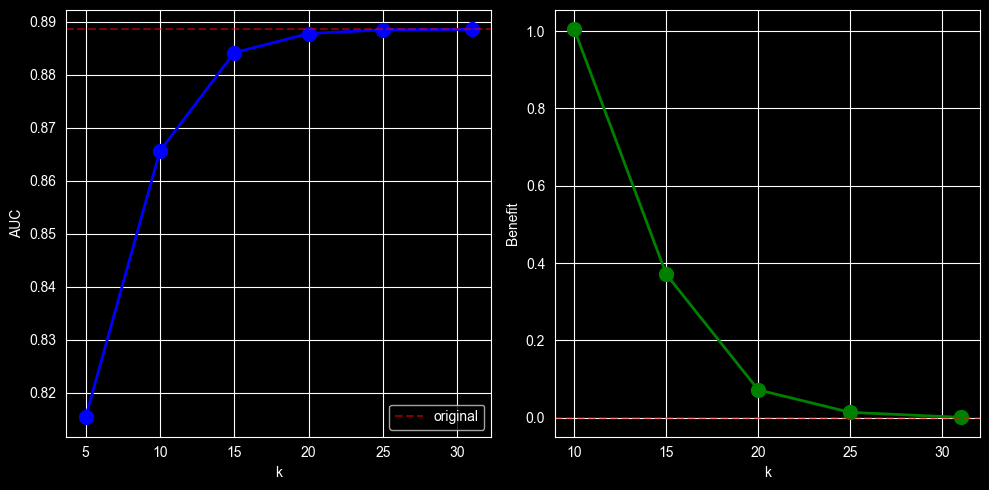

In [15]:
final_model = LogisticRegression(
    l1_ratio=1, C=0.01, solver='saga',
    max_iter=5000, random_state=42,
    class_weight='balanced'
)
final_model.fit(X_train_df, y_train)

feature_coefficients = pd.DataFrame({
    'feature': X_train_df.columns,
    'coefficient': final_model.coef_[0],
    'abs_coefficient': np.abs(final_model.coef_[0])
})

feature_coefficients = feature_coefficients[feature_coefficients['coefficient'] != 0]
feature_coefficients = feature_coefficients.sort_values('abs_coefficient', ascending=False)
feature_coefficients = feature_coefficients.round(4)

print('Feature Rank')
print(feature_coefficients.head(20))

k_values = [5,10,15,20,25,31]
results_topk = []
for k in k_values:
    top_k_features = feature_coefficients.head(k)['feature'].tolist()
    X_train_topk = X_train_df[top_k_features]
    X_val_topk = X_val_df[top_k_features]

    model_topk = LogisticRegression(
        l1_ratio=1, C=0.01, solver='saga',
        max_iter=5000, random_state=42,
        class_weight='balanced'
    )
    model_topk.fit(X_train_topk, y_train)

    y_val_pred = model_topk.predict_proba(X_val_topk)[:,1]
    val_auc = roc_auc_score(y_val, y_val_pred)

    results_topk.append({
        'k': k,
        'feature': top_k_features,
        'val_auc': val_auc,
        'retained_ratio': k/31
    })
    print(f'k={k}:Val AUC = {val_auc:.4f}')

results_topk_df = pd.DataFrame(results_topk)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(results_topk_df['k'],results_topk_df['val_auc'],'bo-',linewidth=2,markersize=10)
axes[0].axhline(y=results_topk_df['val_auc'].iloc[-1],color='r',linestyle='--',alpha=0.5,label='original')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AUC')
axes[0].grid(True)
axes[0].legend()

marginal_benefit = np.diff(results_topk_df['val_auc'])/np.diff(results_topk_df['k'])
axes[1].plot(results_topk_df['k'][1:],marginal_benefit*100,'go-',linewidth=2,markersize=10)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Benefit')
axes[1].axhline(y=0,color='r',linestyle='--',alpha=0.5)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
k_value = 15
top_k_feature = feature_coefficients.head(k_value)['feature'].tolist()
print(top_k_feature)

['gcs_verbal', 'age', 'resp_rate_mean', 'po2_max', 'race_freq', 'gcs_eyes', 'sofa2_liver_24h_max', 'spo2_min', 'gcs_motor', 'heart_rate_mean', 'sofa2_renal_24h_max', 'po2_min', 'glucose_min', 'temperature_mean', 'mbp_min']


In [17]:
feature_names = numeric_col + encoded_cat
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=y_train.index)
X_val_transformed_df = pd.DataFrame(X_val_transformed, columns=feature_names, index=y_val.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names, index=y_test.index)
X_train_selected = X_train_transformed_df[top_k_feature]
X_val_selected = X_val_transformed_df[top_k_feature]
X_test_selected = X_test_transformed_df[top_k_feature]
print('selected train:',X_train_selected.shape)
print('selected val:',X_val_selected.shape)
print('selected test:',X_test_selected.shape)

display(X_train_selected.head())

selected train: (39219, 15)
selected val: (13073, 15)
selected test: (13074, 15)


,,,gcs_verbal,age,resp_rate_mean,po2_max,race_freq,gcs_eyes,sofa2_liver_24h_max,spo2_min,gcs_motor,heart_rate_mean,sofa2_renal_24h_max,po2_min,glucose_min,temperature_mean,mbp_min
subject_id,hadm_id,stay_id,,,,,,,,,,,,,,,
14681582,24873714,37116702,0.784638,-0.561911,-0.427353,-0.092177,0.655861,0.776835,-0.223788,0.059117,0.481863,0.032803,-0.396888,-0.189678,0.070219,-0.293197,0.879759
10574109,20454144,34432800,0.784638,-0.503522,-0.465884,-0.092177,0.655861,0.776835,-0.223788,0.653908,0.481863,0.181130,-0.396888,-0.189678,-0.719264,-0.633349,0.666117
17587304,28802410,35795776,-1.131233,0.430705,-0.777242,-1.618177,0.143515,-2.004242,-0.223788,0.059117,-2.658415,-0.381052,-0.396888,-0.633553,-0.692040,-0.029372,0.096404
10200411,27413133,38024052,0.305670,0.489094,-0.356422,-0.092177,0.143515,0.776835,-0.223788,0.653908,-0.146192,-1.778278,-0.396888,-0.189678,-0.147569,0.334563,0.025189
19498855,29774156,39757881,0.305670,-0.386744,-0.637042,0.931849,0.035431,-0.150191,-0.223788,0.356512,0.481863,-0.396298,5.364393,0.556839,-0.583146,-0.025500,0.381260


# Model implementation

In [18]:
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

In [19]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),
    'SVM': SVC(
        class_weight='balanced',
        random_state=42,
        probability=True
    )
}

In [20]:
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    metrics = {}

    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n Confusion Matrix:")
    print(f"{'':15} {'Predict Survival':>10} {'Predict Death':>10}")
    print(f"{'Actual Survival':15} {tn:10} {fp:10}")
    print(f"{'Actual Death':15} {fn:10} {tp:10}")

    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, zero_division=0)
    metrics['f1'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['specificity'] = tn / (tn + fp) if tn + fp > 0 else 0
    metrics['fnr'] = fn / (fn + tp) if fn + tp > 0 else 0

    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)

    return metrics

all_results = {}
for model_name,pipeline in models.items():
    print(f'\n Training {model_name}...')
    pipeline.fit(X_train_selected, y_train)

    y_pred = pipeline.predict(X_val_selected)
    y_proba = None
    if hasattr(pipeline, 'predict_proba'):
        proba_result = pipeline.predict_proba(X_val_selected)
        if proba_result.shape[1] >= 2:
            y_proba = proba_result[:, 1]

    all_metrics = calculate_metrics(y_val, y_pred, y_proba)
    all_results[model_name] = all_metrics

df = pd.DataFrame(all_results).T.round(4)
important_metrics = ['recall', 'precision', 'f1', 'accuracy','specificity','roc_auc','fnr']
df = df[important_metrics]
print(df.to_string())




 Training Logistic Regression...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival       9759       2180
Actual Death           243        891

 Training Decision Tree...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival      11196        743
Actual Death           742        392

 Training Random Forest...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival      11855         84
Actual Death           878        256

 Training AdaBoost...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival      11755        184
Actual Death           807        327

 Training Gradient Boosting...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival      11778        161
Actual Death           728        406

 Training SVM...

 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival      10068       1871
Actual Death     

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import cross_val_score, StratifiedKFold

from scipy import stats

In [22]:
def smote_test(X_train, y_train, top_models, cv_folds=5):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    results = []
    smote_decisions = {}

    for model_name, model in top_models.items():
        print(f'Testing {model_name}...')
        print(f'-'*50)

        print('\n No SMOTE:')
        no_smote_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
        recall_mean_no = no_smote_score.mean()
        recall_std_no = no_smote_score.std()
        print(f'Recall:{recall_mean_no:.2f} +- {recall_std_no:.2f}')
        print(f'Each fold:{[f'{x:.2f}' for x in no_smote_score]}')

        print('\n Having SMOTE:')
        smote_pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
        with_smote_score = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
        recall_mean_with = with_smote_score.mean()
        recall_std_with = with_smote_score.std()
        print(f'Recall:{recall_mean_with:.2f} +- {recall_std_with:.2f}')
        print(f'Each fold:{[f'{x:.2f}' for x in with_smote_score]}')

        improvement = recall_mean_with-recall_mean_no
        relative_improvement = (improvement / recall_mean_no) * 100 if recall_mean_no > 0 else 0
        print(f'Improvement:{improvement:.2f}')
        print(f'Relative Improvement:{relative_improvement:.2f}%')

        t_stat, p_value = stats.ttest_rel(with_smote_score, no_smote_score)
        print(f'\n t-stat:{t_stat:.2f}, p-value:{p_value:.4f}')

        use_smote = (improvement > 0.02) and (p_value < 0.1)
        if use_smote:
            print(f'Using SMOTE')
        else:
            if improvement <= 0.02:
                print(f'No SMOTE (No obevious improvement)\n')
            elif p_value >= 0.1:
                print(f'No SMOTE (Statistically insignificant)\n')
        smote_decisions[model_name] = use_smote
        results.append({
            'model_name': model_name,
            'recall_mean_no': recall_mean_no,
            'recall_std_no': recall_std_no,
            'recall_mean_with': recall_mean_with,
            'recall_std_with': recall_std_with,
            'improvement': improvement,
            'relative_improvement': relative_improvement,
            'p_value': p_value,
            'whether SMOTE is used': 'Yes' if use_smote else 'No'
        })
    results_df = pd.DataFrame(results)
    results_df = results_df.round(4)

    print('Summary')
    print(results_df.to_string(index=False))

    return smote_decisions, results_df

In [23]:
top_model_names = ['Logistic Regression', 'SVM']
top_models = {}
for name in top_model_names:
    top_models[name] = models[name]

smote_decisions = smote_test(X_val_selected, y_val, top_models)

Testing Logistic Regression...
--------------------------------------------------

 No SMOTE:
Recall:0.78 +- 0.03
Each fold:['0.74', '0.75', '0.79', '0.77', '0.83']

 Having SMOTE:
Recall:0.78 +- 0.03
Each fold:['0.74', '0.76', '0.78', '0.79', '0.82']
Improvement:0.00
Relative Improvement:0.00%

 t-stat:0.00, p-value:0.9977
No SMOTE (No obevious improvement)

Testing SVM...
--------------------------------------------------

 No SMOTE:
Recall:0.75 +- 0.04
Each fold:['0.69', '0.73', '0.73', '0.78', '0.81']

 Having SMOTE:
Recall:0.72 +- 0.04
Each fold:['0.67', '0.70', '0.72', '0.74', '0.78']
Improvement:-0.03
Relative Improvement:-3.42%

 t-stat:-6.72, p-value:0.0026
No SMOTE (No obevious improvement)

Summary
         model_name  recall_mean_no  recall_std_no  recall_mean_with  recall_std_with  improvement  relative_improvement  p_value whether SMOTE is used
Logistic Regression          0.7769         0.0297            0.7769           0.0270       0.0000                0.0020   0.9977

## Parameter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
def tune_logistic_regression(X_train, y_train, X_val, y_val):
    lr = LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
    )
    param_grids = [
        {
            'C':[0.01, 0.1, 1, 10, 100],
            'l1_ratio':[0, 1],
            'solver':['liblinear']
        },
        {
            'C':[0.01, 0.1, 1, 10, 100],
            'l1_ratio':[0],
            'solver':['sag', 'lbfgs', 'newton-cg']
        },
        {
            'C':[0.01, 0.1, 1, 10, 100],
            'solver':['saga'],
            'l1_ratio':[0.1, 0.3, 0.5, 0.7, 0.9]
        }
    ]
    grid_search = GridSearchCV(
        lr,
        param_grids,
        cv=5,
        scoring='recall',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    print(f'\nBest parameters:{grid_search.best_params_}')
    print(f'Best score:{grid_search.best_score_:.2f}')

    best_lr = grid_search.best_estimator_
    y_val_pred = best_lr.predict(X_val)
    val_recall = recall_score(y_val, y_val_pred)
    print(f'\n Recall:{val_recall:.2f}')

    if hasattr(best_lr, 'coef_'):
        coef = best_lr.coef_[0]
        print(f'\n Feature importance:')
        feature_importance = pd.DataFrame({
            'feature': top_k_feature,
            'coefficient': coef,
            'abs_coef': np.abs(coef)
        }).sort_values('abs_coef', ascending=False)
        feature_importance = feature_importance.round(4)
        print(feature_importance.head(5))

    return best_lr, grid_search.best_params_

def tune_svm(X_train, y_train, X_val, y_val):
    svm = SVC(class_weight='balanced', random_state=42, probability=True)

    param_grid_kernel = {
        'kernel': ['linear', 'poly', 'rbf'],
        'C':[1],
        'gamma':['scale']
    }
    grid_kernel = GridSearchCV(
        svm,
        param_grid_kernel,
        cv=3,
        scoring='recall',
        n_jobs=-1,
    )
    grid_kernel.fit(X_train, y_train)
    best_kernel = grid_kernel.best_params_['kernel']
    print(f'Best Kernel:{best_kernel}')

    if best_kernel == 'linear':
        param_grid = {
            'kernel':['linear'],
            'C':[0.1, 1, 10]
        }
    elif best_kernel == 'rbf':
        param_grid = {
            'kernel':['rbf'],
            'C':[0.01, 0.1, 1, 10, 100],
            'gamma':['scale', 'auto', 0.1, 0.01, 0.001]
        }
    else:
        param_grid = {
            'kernel':['poly'],
            'C':[0.01, 0.1, 1, 10, 100],
            'gamma':['scale', 'auto'],
            'degree':[2,3,4],
            'coef0':[0,1]
        }

    grid_final = GridSearchCV(
        svm,
        param_grid,
        cv=3,
        scoring='recall',
        n_jobs=-1,
        verbose=1
    )

    grid_final.fit(X_train, y_train)
    print(f'\nBest parameters:{grid_final.best_params_}')
    print(f' Best score:{grid_final.best_score_:.4f}')

    best_svm = grid_final.best_estimator_
    y_val_pred = best_svm.predict(X_val)
    val_recall = recall_score(y_val, y_val_pred)
    print(f'\n Recall:{val_recall:.4f}')

    return best_svm, grid_final.best_params_

In [26]:
tune_results = {}
best_tune_models = {}

print(f'\n Tuning Logistic Regression:')
lr_best, lr_params = tune_logistic_regression(X_train_selected, y_train, X_val_selected, y_val)
y_val_pred_lr = lr_best.predict(X_val_selected)
lr_val_recall = recall_score(y_val, y_val_pred_lr)
lr_val_auc = roc_auc_score(y_val, lr_best.predict_proba(X_val_selected)[:, 1])

tune_results['Logistic Regression'] = {
    'best_params': lr_params,
    'val_recall': lr_val_recall,
    'val_auc': lr_val_auc,
    'model':lr_best
}

print(f'\n Tuning SVM:')
svm_best, svm_params = tune_svm(X_train_selected, y_train, X_val_selected, y_val)
y_val_pred_svm = svm_best.predict(X_val_selected)
svm_val_recall = recall_score(y_val, y_val_pred_svm)
svm_val_auc = roc_auc_score(y_val, svm_best.predict_proba(X_val_selected)[:, 1])

tune_results['SVM'] = {
    'best_params': svm_params,
    'val_recall': svm_val_recall,
    'val_auc': svm_val_auc,
    'model':svm_best
}

print('\n Tuning Result Comparison:')
tune_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Recall': [lr_val_recall, svm_val_recall],
    'AUC': [lr_val_auc, svm_val_auc]
})
print(tune_comparison.round(4).to_string(index=False))

if lr_val_recall > svm_val_recall:
    print('\n Choosing Logistic Regression')
    best_model = lr_best
    best_name = 'Logistic Regression'
else:
    print('\n Choosing SVM')
    best_model = svm_best
    best_name = 'SVM'


 Tuning Logistic Regression:
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:{'C': 0.01, 'l1_ratio': 0, 'solver': 'liblinear'}
Best score:0.79

 Recall:0.79

 Feature importance:
          feature  coefficient  abs_coef
4       race_freq      -0.5958    0.5958
0      gcs_verbal      -0.5112    0.5112
2  resp_rate_mean       0.4806    0.4806
1             age       0.4435    0.4435
3         po2_max      -0.4258    0.4258

 Tuning SVM:
Best Kernel:linear
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:{'C': 0.1, 'kernel': 'linear'}
 Best score:0.8022

 Recall:0.7866

 Tuning Result Comparison:
              Model  Recall    AUC
Logistic Regression  0.7857 0.8843
                SVM  0.7866 0.8840

 Choosing SVM


## Final Evaluation

In [27]:
def final_evaluation(best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n Confusion Matrix:")
    print(f"{'':15} {'Predict Survival':>10} {'Predict Death':>10}")
    print(f"{'Actual Survival':15} {tn:10} {fp:10}")
    print(f"{'Actual Death':15} {fn:10} {tp:10}")

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Specificity': float(tn/(tn+fp)),
        'AUC': roc_auc_score(y_test, y_proba)
    }
    metrics = {k: round(v,4) for k, v in metrics.items()}

    print('\n Evaluation Metrics:')
    for name, value in metrics.items():
        print(f'{name}: {value:.4f}')

    print('\n Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Death']))

    results = pd.DataFrame({
        'Patient_id': y_test.index,
        'true_label': y_test,
        'predicted_label': y_pred,
        'predicted probability': y_proba
    })

    return metrics

metrics = final_evaluation(best_model, X_test_selected, y_test)
print(metrics)


 Confusion Matrix:
                Predict Survival Predict Death
Actual Survival       9639       2301
Actual Death           229        905

 Evaluation Metrics:
Accuracy: 0.8065
Precision: 0.2823
Recall: 0.7981
F1: 0.4171
Specificity: 0.8073
AUC: 0.8871

 Classification Report:
              precision    recall  f1-score   support

    Survived       0.98      0.81      0.88     11940
       Death       0.28      0.80      0.42      1134

    accuracy                           0.81     13074
   macro avg       0.63      0.80      0.65     13074
weighted avg       0.92      0.81      0.84     13074

{'Accuracy': 0.8065, 'Precision': 0.2823, 'Recall': 0.7981, 'F1': 0.4171, 'Specificity': 0.8073, 'AUC': 0.8871}


## Threshold Optimization

In [28]:
from sklearn.metrics import precision_recall_curve


Best Threshold:0.0792
Best Recall:0.8007
Best Precision:0.2742


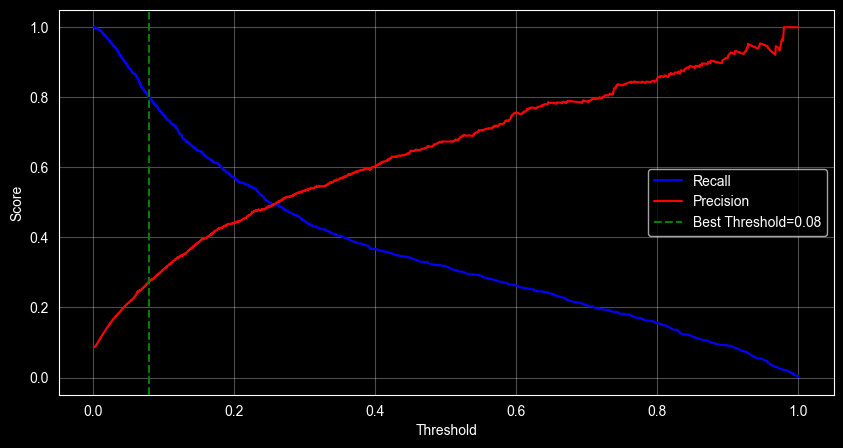

0.0792

In [29]:
def threshold_optimization(model, X_val, y_val):
    y_proba = model.predict_proba(X_val)[:, 1]

    precision, recall, threshold = precision_recall_curve(y_val, y_proba)

    target_threshold = 0.8
    valid_indices = np.where(recall[:-1] >= target_threshold)[0]

    if len(valid_indices) > 0:
        best_idx = valid_indices[-1]
        best_threshold = threshold[best_idx]
        best_recall = recall[best_idx]
        best_precision = precision[best_idx]

        print(f'\nBest Threshold:{best_threshold:.4f}')
        print(f'Best Recall:{best_recall:.4f}')
        print(f'Best Precision:{best_precision:.4f}')

        y_pred_new = (y_proba >= best_threshold).astype(int)

        plt.figure(figsize=(10, 5))
        plt.plot(threshold, recall[:-1,], 'b-', label='Recall')
        plt.plot(threshold, precision[:-1,], 'r-', label='Precision')
        plt.axvline(x=best_threshold, color='g', linestyle='--', label=f'Best Threshold={best_threshold:.2f}')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        return float(round(best_threshold, 4))
    else:
        print(f'Cannot achieve target threshold {target_threshold} ')
        return 0.5

threshold_optimization(best_model, X_val_selected, y_val)

## Model interpretation


 Characteristic coefficients:
       feature    coef  abs_coef
     race_freq -0.4863    0.4863
    gcs_verbal -0.3820    0.3820
resp_rate_mean  0.3684    0.3684
       po2_max -0.3656    0.3656
           age  0.3468    0.3468


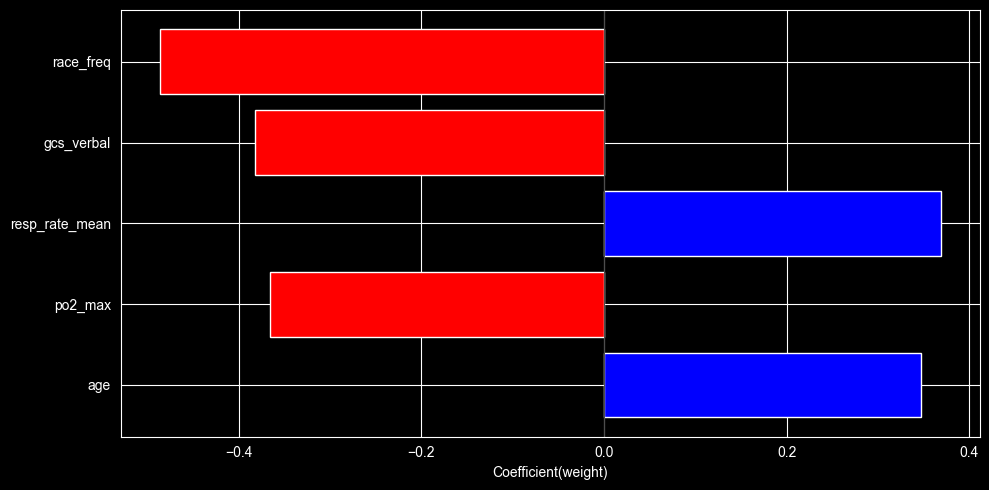


 Predictive probability analysis


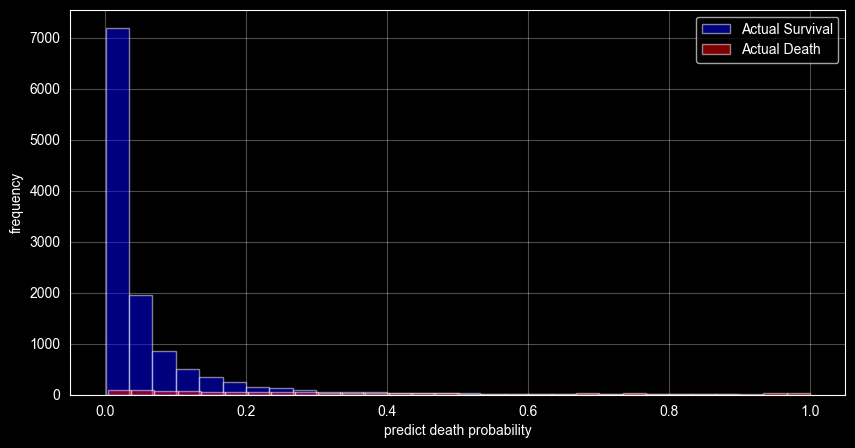


 Decision Function Analysis


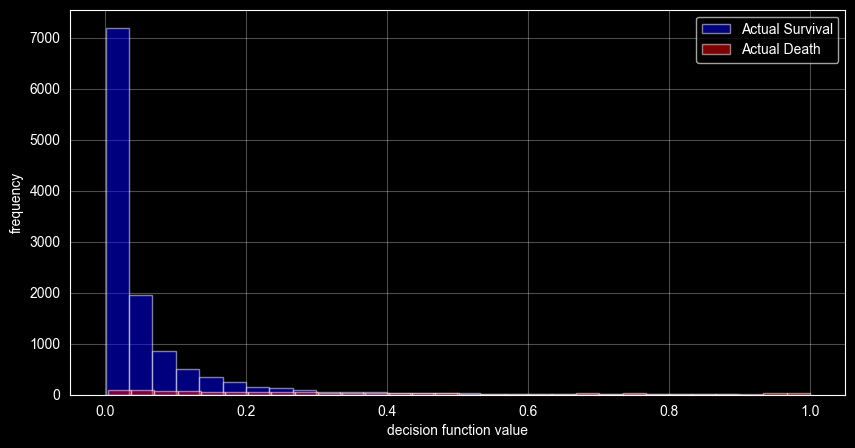


 sample size of wrong prediction: 2530

 number of missed cases: 229


In [30]:
def model_interpretation(model, feature_names, X_test, y_test):
    coef = model.coef_[0]

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coef': coef,
        'abs_coef': np.abs(coef)
    }).sort_values('abs_coef', ascending=False)
    coef_df = coef_df.round(4)

    print('\n Characteristic coefficients:')
    print(coef_df.head(5).to_string(index=False))

    plt.figure(figsize=(10, 5))
    colors = ['red' if c < 0 else 'blue' for c in coef_df.head(5)['coef']]
    plt.barh(coef_df.head(5)['feature'],
             coef_df.head(5)['coef'],
             color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient(weight)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    if hasattr(model, 'predict_proba'):
        print('\n Predictive probability analysis')
        y_proba = model.predict_proba(X_test)[:, 1]

        plt.figure(figsize=(10, 5))
        plt.hist(y_proba[y_test.values == 0], bins=30, alpha=0.5, label='Actual Survival', color='blue')
        plt.hist(y_proba[y_test.values == 1], bins=30, alpha=0.5, label='Actual Death', color='red')
        plt.xlabel('predict death probability')
        plt.ylabel('frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    print('\n Decision Function Analysis')
    decision_values = model.decision_function(X_test)

    plt.figure(figsize=(10, 5))
    plt.hist(y_proba[y_test.values == 0], bins=30, alpha=0.5, label='Actual Survival', color='blue')
    plt.hist(y_proba[y_test.values == 1], bins=30, alpha=0.5, label='Actual Death', color='red')
    plt.xlabel('decision function value')
    plt.ylabel('frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    y_pred = model.predict(X_test)
    errors = X_test[y_test != y_pred]
    print(f'\n sample size of wrong prediction: {len(errors)}')

    fn_indices = y_test.index[(y_test == 1) & (y_pred == 0)]
    print(f'\n number of missed cases: {len(fn_indices)}')

model_interpretation(best_model, top_k_feature, X_test_selected, y_test)

## Final Training

In [31]:
def final_training(best_model, X_all, y_all):
    if hasattr(best_model, 'get_params'):
        best_params = best_model.get_params()

        exclude_params = ['shape_fit_', 'n_features_in_', 'classes_', 'support_', 'support_vectors_', 'n_support_',
        'dual_coef_', 'coef_', 'intercept_', 'probA_', 'probB_']

        init_params = {k: v for k, v in best_params.items()
                      if k not in exclude_params and not k.endswith('_')}

        for key, value in init_params.items():
            print(f'{key}: {value}')

        final_model = SVC(**init_params)

        print(f'\n Training Final Model, data volume: {X_all.shape}')
        final_model.fit(X_all, y_all)
        print(' Final Training Finished')

        return final_model
    else:
        print('No parameters, using original model')
        return best_model

X_selected = pd.concat([X_train_selected, X_val_selected, X_test_selected], axis=0, ignore_index=True)
final_training(best_model, X_selected, y)

C: 0.1
break_ties: False
cache_size: 200
class_weight: balanced
coef0: 0.0
decision_function_shape: ovr
degree: 3
gamma: scale
kernel: linear
max_iter: -1
probability: True
random_state: 42
shrinking: True
tol: 0.001
verbose: False

 Training Final Model, data volume: (65366, 15)
 Final Training Finished


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
